In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
orders = pd.read_csv("olist_orders_dataset.csv")
items = pd.read_csv("olist_order_items_dataset.csv")
reviews = pd.read_csv("olist_order_reviews_dataset.csv")
customers = pd.read_csv("olist_customers_dataset.csv")

In [3]:
df = orders.merge(items, on="order_id", how="left")
df = df.merge(reviews, on="order_id", how="left")
df = df.merge(customers, on="customer_id", how="left")

In [4]:
df = df[df["order_status"] == "delivered"]

In [5]:
df["order_purchase_timestamp"] = pd.to_datetime(
    df["order_purchase_timestamp"])

In [6]:
df["YearMonth"] = df["order_purchase_timestamp"].dt.to_period("M")

In [7]:
cohort = df.groupby("customer_unique_id")["YearMonth"].min().reset_index()
cohort.columns = ["customer_unique_id", "CohortMonth"]

In [8]:
df = df.merge(cohort, on="customer_unique_id")

In [9]:
df["CohortIndex"] = ((df["YearMonth"].dt.year - df["CohortMonth"].dt.year) * 12
    + (df["YearMonth"].dt.month - df["CohortMonth"].dt.month))

In [10]:
cohort_data = df.groupby(
    ["CohortMonth", "CohortIndex"])["customer_unique_id"].nunique().reset_index()

In [11]:
cohort_table = cohort_data.pivot(
    index="CohortMonth",
    columns="CohortIndex",
    values="customer_unique_id")

In [12]:
retention = cohort_table.divide(
    cohort_table[0],
    axis=0)

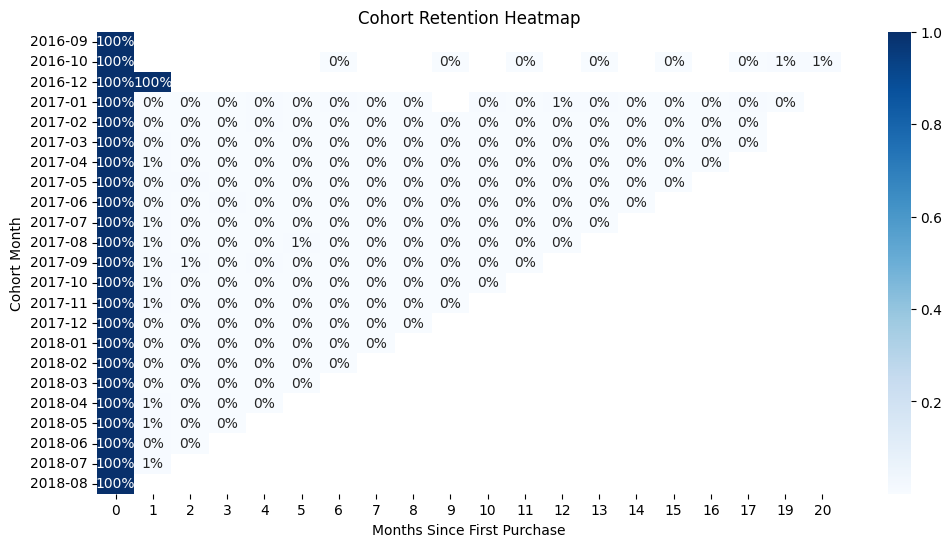

In [15]:
plt.figure(figsize=(12,6))
sns.heatmap(retention,annot=True,fmt=".0%",cmap="Blues")
plt.title("Cohort Retention Heatmap")
plt.xlabel("Months Since First Purchase")
plt.ylabel("Cohort Month")
plt.show()

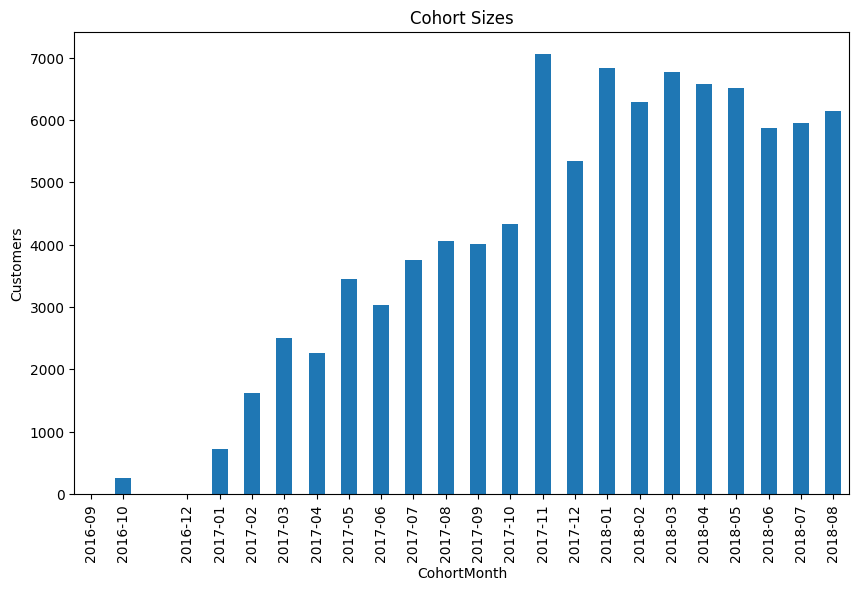

In [17]:
cohort_size = cohort_table[0]
plt.figure(figsize=(10,6))
cohort_size.plot(kind="bar")
plt.title("Cohort Sizes")
plt.ylabel("Customers")
plt.show()

In [19]:
df["order_delivered_customer_date"] = pd.to_datetime(
    df["order_delivered_customer_date"])
df["DeliveryDays"] = (
    df["order_delivered_customer_date"]
    - df["order_purchase_timestamp"]).dt.days

In [20]:
delivery_review = df.groupby(
    pd.cut(df["DeliveryDays"], bins=[0,5,10,15,20,30,60]))["review_score"].mean()

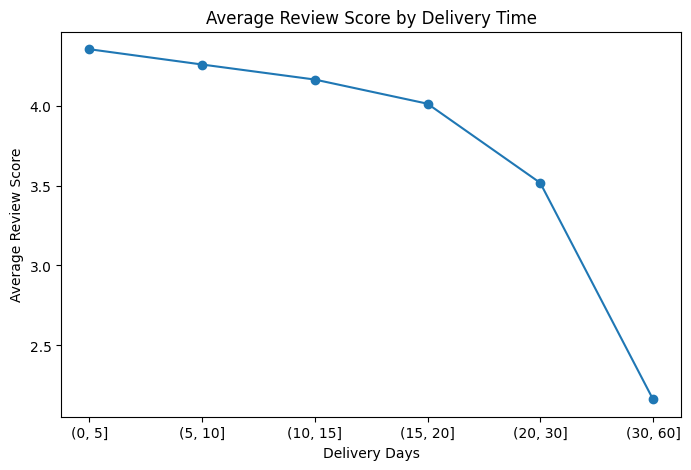

In [22]:
plt.figure(figsize=(8,5))
delivery_review.plot(marker="o")
plt.title("Average Review Score by Delivery Time")
plt.ylabel("Average Review Score")
plt.xlabel("Delivery Days")
plt.show()

In [23]:
products = pd.read_csv("olist_products_dataset.csv")
translation = pd.read_csv("product_category_name_translation.csv") #bonus ucun

In [24]:
products = products.merge(translation,on="product_category_name",how="left")

In [25]:
df = df.merge(
    products[["product_id", "product_category_name_english"]],
    on="product_id",
    how="left")

In [26]:
electronics = df[df["product_category_name_english"].str.contains("electronics|computers|audio",case=False,na=False)]

In [27]:
fashion = df[df["product_category_name_english"].str.contains( "fashion|clothes|apparel",case=False,na=False)]

In [28]:
def create_retention(data):
    cohort_data = data.groupby(
        ["CohortMonth", "CohortIndex"]
    )["customer_unique_id"].nunique().reset_index()
    cohort_table = cohort_data.pivot(
        index="CohortMonth",
        columns="CohortIndex",
        values="customer_unique_id")
    retention = cohort_table.divide(
        cohort_table[0],
        axis=0)
    return retention

In [29]:
electronics_retention = create_retention(electronics)
fashion_retention = create_retention(fashion)

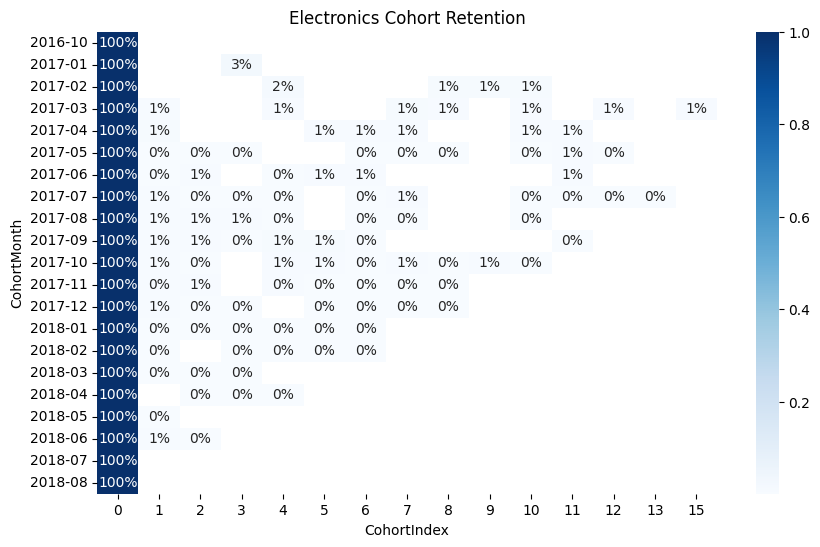

In [31]:
plt.figure(figsize=(10,6))
sns.heatmap(
    electronics_retention,
    annot=True,
    fmt=".0%",
    cmap="Blues")
plt.title("Electronics Cohort Retention")
plt.show()

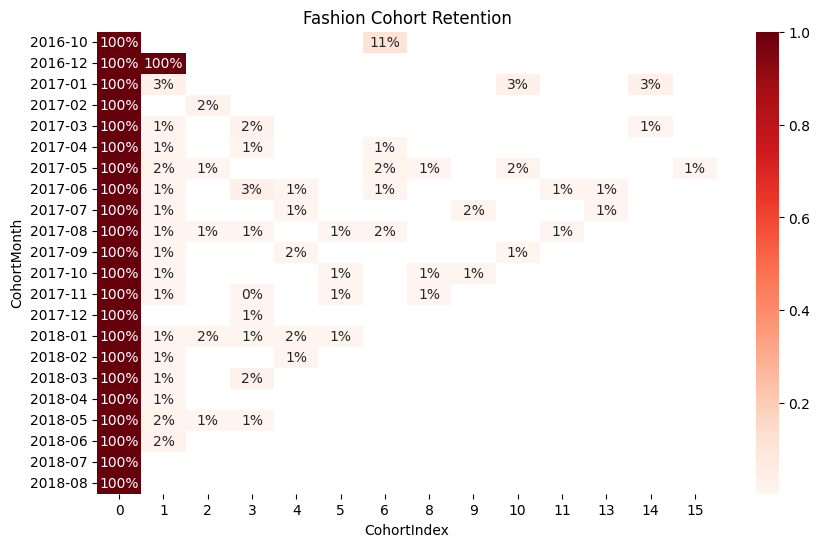

In [32]:
plt.figure(figsize=(10,6))
sns.heatmap(
    fashion_retention,
    annot=True,
    fmt=".0%",
    cmap="Reds")
plt.title("Fashion Cohort Retention")
plt.show()

In [ ]:
top3 = cohort_table[0].sort_values(
    ascending=False).head(3)
print(top3) #bonus

CohortMonth
2017-11    7060.0
2018-01    6842.0
2018-03    6774.0
Freq: M, Name: 0, dtype: float64


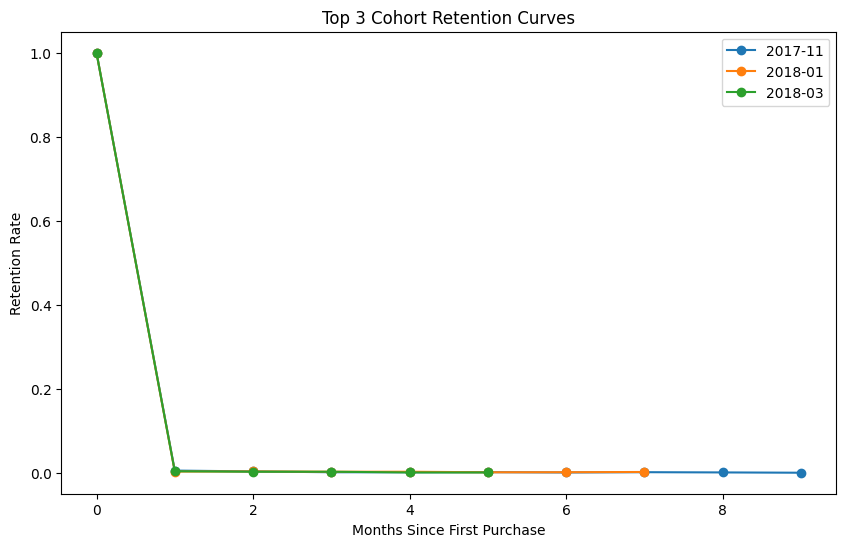

In [35]:
plt.figure(figsize=(10,6))
for cohort in top3.index:
    plt.plot(
        retention.columns,
        retention.loc[cohort],
        marker="o",
        label=str(cohort))
plt.title("Top 3 Cohort Retention Curves")
plt.xlabel("Months Since First Purchase")
plt.ylabel("Retention Rate")
plt.legend()
plt.show()